In [1]:
from warnings import filterwarnings
import random

import torch.cuda as cuda

import sys
sys.path.append('../')

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 训练使用真实标签

In [2]:
output_dir = '../output/pbmc_benchmark_data_with_true_label/'
adata = sc.read_h5ad(output_dir + 'adata_train.h5ad')
adata

AnnData object with n_obs × n_vars = 30669 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [4]:
node_ids = np.load(output_dir + "/Node_Ids.npy")
cell_emb = np.load(output_dir + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

AnnData object with n_obs × n_vars = 30669 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'cell_emb'
    layers: 'counts'

In [6]:
pred = np.load(output_dir + '/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [8]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

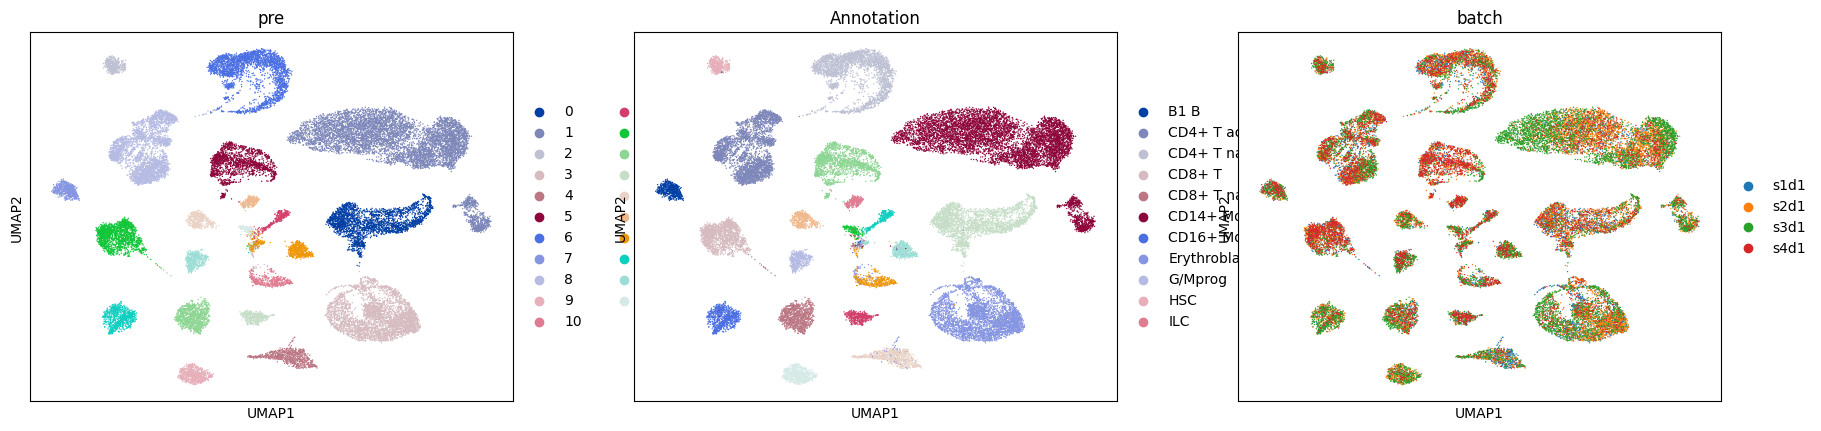

In [18]:
sc.pl.umap(adata, color=['pre', 'Annotation', 'batch'], show=True)

In [15]:
annotation_to_num = {ann: idx for idx, ann in enumerate(adata.obs['Annotation'].unique())}
# Create a new column with numerical labels
adata.obs['Annotation_num'] = adata.obs['Annotation'].map(annotation_to_num)

In [16]:
from sklearn.metrics import f1_score

# 提取真实标签和预测结果
true_labels = adata.obs['Annotation_num']
pred_labels = adata.obs['pre']

# 计算每类细胞的比例
cell_counts = true_labels.value_counts(normalize=True)

# 筛选 5%-1% 和 <1% 的细胞类别
rare_5_1 = cell_counts[(cell_counts <= 0.05) & (cell_counts > 0.01)].index
rare_below_1 = cell_counts[cell_counts <= 0.01].index

# 定义一个函数计算 F1 分数
def calculate_f1_for_classes(true_labels, pred_labels, target_classes):
    mask = true_labels.isin(target_classes)
    true_subset = true_labels[mask]
    pred_subset = pred_labels[mask]
    return f1_score(true_subset, pred_subset, average='weighted')

# 计算两个区间的 F1 分数
f1_5_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_5_1)
f1_below_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_below_1)

# 输出结果
print(f"F1 Score for 5%-1% rare cells: {f1_5_1}")
print(f"F1 Score for <1% rare cells: {f1_below_1}")


F1 Score for 5%-1% rare cells: 0.9777375060408392
F1 Score for <1% rare cells: 0.9341439552166463


## 不使用真实标签的情况

In [19]:
output_dir = '../output/pbmc_benchmark_data_without_true_label/'
adata = sc.read_h5ad(output_dir + 'adata_train.h5ad')
adata

AnnData object with n_obs × n_vars = 30669 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [20]:
node_ids = np.load(output_dir + "/Node_Ids.npy")
cell_emb = np.load(output_dir + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

AnnData object with n_obs × n_vars = 30669 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'cell_emb'
    layers: 'counts'

In [21]:
pred = np.load(output_dir + '/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [22]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

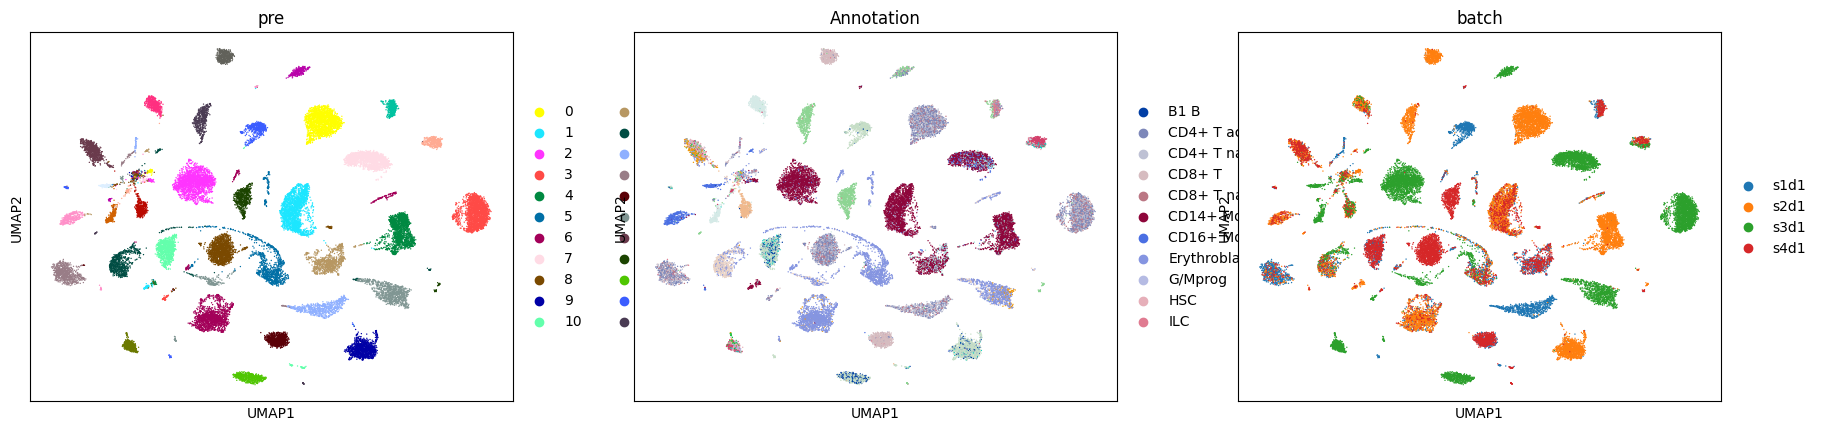

In [23]:
sc.pl.umap(adata, color=['pre', 'Annotation', 'batch'], show=True)

In [25]:
annotation_to_num = {ann: idx for idx, ann in enumerate(adata.obs['Annotation'].unique())}
# Create a new column with numerical labels
adata.obs['Annotation_num'] = adata.obs['Annotation'].map(annotation_to_num)

In [26]:
from sklearn.metrics import f1_score

# 提取真实标签和预测结果
true_labels = adata.obs['Annotation_num']
pred_labels = adata.obs['pre']

# 计算每类细胞的比例
cell_counts = true_labels.value_counts(normalize=True)

# 筛选 5%-1% 和 <1% 的细胞类别
rare_5_1 = cell_counts[(cell_counts <= 0.05) & (cell_counts > 0.01)].index
rare_below_1 = cell_counts[cell_counts <= 0.01].index

# 定义一个函数计算 F1 分数
def calculate_f1_for_classes(true_labels, pred_labels, target_classes):
    mask = true_labels.isin(target_classes)
    true_subset = true_labels[mask]
    pred_subset = pred_labels[mask]
    return f1_score(true_subset, pred_subset, average='weighted')

# 计算两个区间的 F1 分数
f1_5_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_5_1)
f1_below_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_below_1)

# 输出结果
print(f"F1 Score for 5%-1% rare cells: {f1_5_1}")
print(f"F1 Score for <1% rare cells: {f1_below_1}")

F1 Score for 5%-1% rare cells: 0.033537738125683156
F1 Score for <1% rare cells: 0.0


In [28]:
adata = sc.read_h5ad('../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad')
adata

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [29]:
node_ids = np.load('../output/pbmc_benchmark_data/Node_Ids.npy')
cell_emb = np.load('../output/pbmc_benchmark_data/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'cell_emb'
    layers: 'counts'

In [30]:
pred = np.load('../output/pbmc_benchmark_data/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [31]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

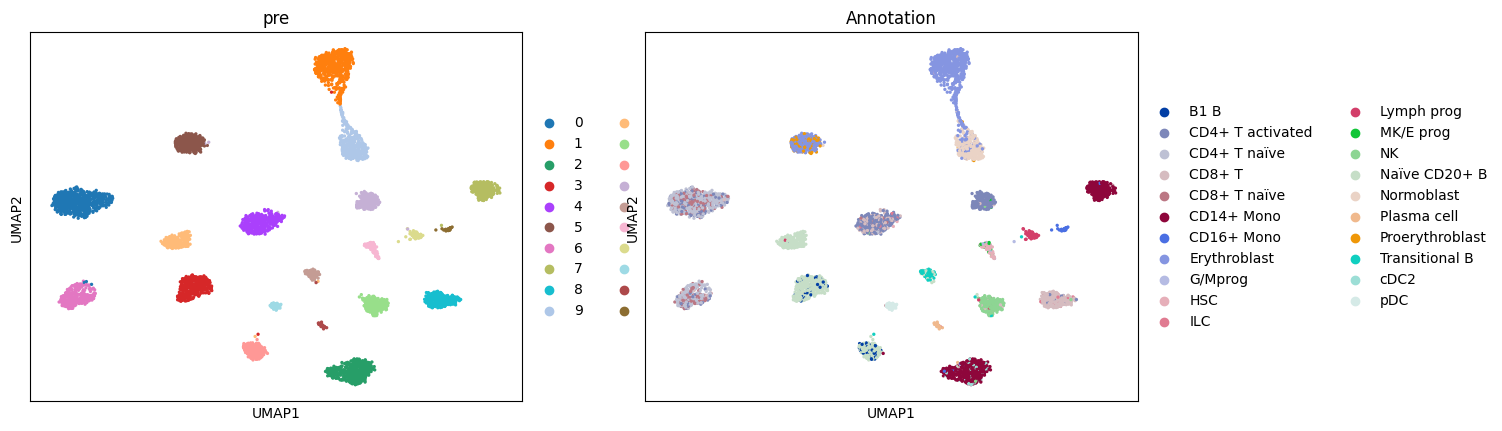

In [32]:
sc.pl.umap(adata, color=['pre', 'Annotation'], show=True)

In [55]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# 1. 计算每种类型的细胞数量和比例
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 2. 筛选目标细胞类型
target_cell_types_1_5 = cell_type_proportions[
    (cell_type_proportions > 0.01) & (cell_type_proportions < 0.05)
].index.tolist()

target_cell_types_below_1 = cell_type_proportions[
    cell_type_proportions < 0.01
].index.tolist()

print("5%-1% 稀有细胞类型：", target_cell_types_1_5)
print("<1% 稀有细胞类型：", target_cell_types_below_1)

# 3. 标记稀有细胞的真实标签
adata.obs['Target_1_5'] = adata.obs['Annotation'].isin(target_cell_types_1_5)
adata.obs['Target_below_1'] = adata.obs['Annotation'].isin(target_cell_types_below_1)

# 转换为二值标签
adata.obs['Target_str_1_5'] = adata.obs['Target_1_5'].map({True: 'Target', False: 'Non-Target'})
adata.obs['Target_str_below_1'] = adata.obs['Target_below_1'].map({True: 'Target', False: 'Non-Target'})

# 4. 计算每个簇的比例
pre_labels = adata.obs['pre']
cluster_counts = pre_labels.value_counts(normalize=True)  # 计算簇比例

# 筛选稀有簇
rare_clusters_1_5 = cluster_counts[
    (cluster_counts >= 0.01) & (cluster_counts < 0.05)
].index.tolist()

rare_clusters_below_1 = cluster_counts[
    cluster_counts < 0.01
].index.tolist()

# 5. 标记预测稀有细胞
adata.obs['predicted_rare_1_5'] = pre_labels.apply(lambda x: 1 if x in rare_clusters_1_5 else 0)
adata.obs['predicted_rare_below_1'] = pre_labels.apply(lambda x: 1 if x in rare_clusters_below_1 else 0)

# 6. 提取真实标签和预测标签
true_labels_1_5 = np.where(adata.obs['Target_str_1_5'] == 'Target', 1, 0)
predicted_labels_1_5 = adata.obs['predicted_rare_1_5']

true_labels_below_1 = np.where(adata.obs['Target_str_below_1'] == 'Target', 1, 0)
predicted_labels_below_1 = adata.obs['predicted_rare_below_1']

# 7. 计算 F1 值
f1_1_5 = f1_score(true_labels_1_5, predicted_labels_1_5)
f1_below_1 = f1_score(true_labels_below_1, predicted_labels_below_1)

print("F1 Score for 5%-1% Rare Cells:", f1_1_5)
print("F1 Score for <1% Rare Cells:", f1_below_1)

# 8. 输出分类报告
report_1_5 = classification_report(true_labels_1_5, predicted_labels_1_5, target_names=['Non-Target', 'Target'])
report_below_1 = classification_report(true_labels_below_1, predicted_labels_below_1, target_names=['Non-Target', 'Target'])

print("\nClassification Report for 5%-1% Rare Cells:\n", report_1_5)
print("\nClassification Report for <1% Rare Cells:\n", report_below_1)


5%-1% 稀有细胞类型： ['CD8+ T naïve', 'NK', 'Proerythroblast', 'B1 B', 'Transitional B', 'Lymph prog', 'HSC', 'pDC']
<1% 稀有细胞类型： ['CD16+ Mono', 'Plasma cell', 'cDC2', 'ILC', 'MK/E prog', 'G/Mprog']
F1 Score for 5%-1% Rare Cells: 0.5026328386787937
F1 Score for <1% Rare Cells: 0.5726141078838174

Classification Report for 5%-1% Rare Cells:
               precision    recall  f1-score   support

  Non-Target       0.91      0.85      0.88      4328
      Target       0.44      0.58      0.50       899

    accuracy                           0.80      5227
   macro avg       0.67      0.72      0.69      5227
weighted avg       0.83      0.80      0.81      5227


Classification Report for <1% Rare Cells:
               precision    recall  f1-score   support

  Non-Target       0.98      1.00      0.99      5056
      Target       0.99      0.40      0.57       171

    accuracy                           0.98      5227
   macro avg       0.98      0.70      0.78      5227
weighted avg       0.9

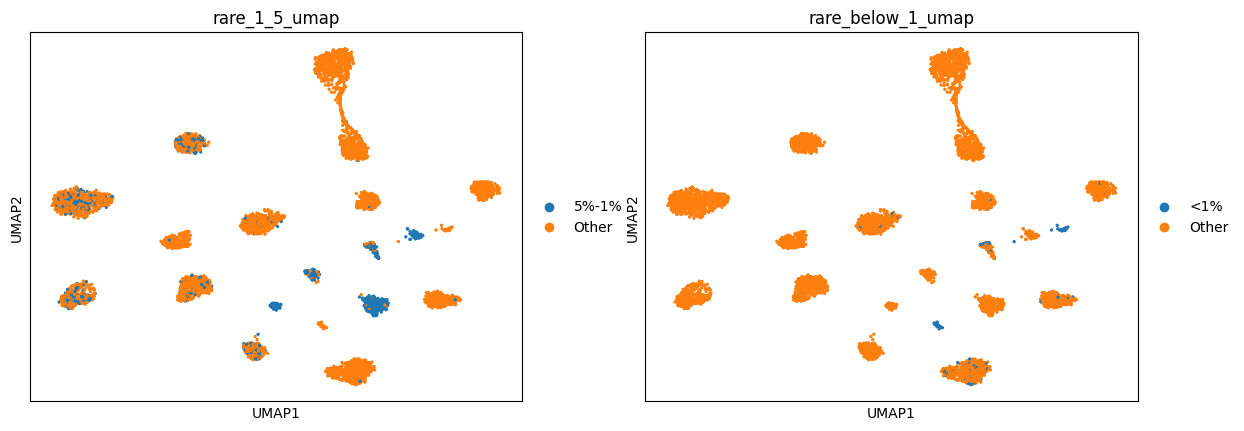

In [56]:
adata.obs['rare_1_5_umap'] = adata.obs['Annotation'].apply(
    lambda x: '5%-1%' if x in target_cell_types_1_5 else 'Other'
)

# 2. 在 adata.obs 中标记 <1% 的稀有细胞
adata.obs['rare_below_1_umap'] = adata.obs['Annotation'].apply(
    lambda x: '<1%' if x in target_cell_types_below_1 else 'Other'
)

sc.pl.umap(adata, color=['rare_1_5_umap', 'rare_below_1_umap'], show=True)
